In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# Promoter-level chec-seq signal (sumprom) for Human TFs
sumprom_chec_glob = "sumproms/*gz"

# Promoter-level chec-seq signal (sumprom) for yeast TFs (see manuscript)
yeast_tf_sumprom_glob = '../Yeast_Native_TF_outfiles/results/sumproms/*.gz'

# Clustal Omega sequence similarity matrix paths
dbd_similarity_filepath = "metadata/dbd_similarity_clustalo.pim"
nondbd_similarity_filepath = "metadata/nondbd_similarity_clustalo.pim"

## Imports

In [3]:
import numpy as np
import pandas as pd

from scipy.stats import zscore
from scipy.stats import spearmanr

import glob

from itertools import combinations

import matplotlib.pyplot as plt

In [4]:
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {"FOXK1": FOXK1_WT, "GABPA": GABPA_WT, "SOX10": SOX10_WT, "HXD10": HXD10_WT, "GATA1": GATA1_WT, "BATF3": BATF3_WT, "HEY1": HEY1_WT, "NFAC4": NFAC4_WT, "TF2LY": TF2LY_WT, "PO3F2": PO3F2_WT}

In [5]:
supmrom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in supmrom_chec_files], axis=1)

corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
cols_to_keep = set(sum(dbd_fam_dict.values(), []))
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom = sumprom.loc[:, sumprom.columns.intersection(cols_to_keep)]
sumprom_z=sumprom.apply(zscore)
sumprom_z_corr = sumprom_z.corr()

## Load Percent Identity Matrixes (.pim files from ClustalO)
https://www.ebi.ac.uk/jdispatcher/msa/clustalo

In [6]:
def read_pim(filepath):
    names = []
    matrix = []

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            # Skip comments or empty lines
            if not line or line.startswith("#"):
                continue
            # Split at colon to remove index
            left, right = line.split(":", 1)
            # First token after colon is the name
            parts = right.strip().split()
            name = parts[0]
            values = parts[1:]
            # Convert values to float (handle -nan)
            values = [float(v) if v.lower() != "-nan" else np.nan for v in values]
            names.append(name)
            matrix.append(values)
    df = pd.DataFrame(matrix, index=names, columns=names)
    return df

dbd_similarity = read_pim(dbd_similarity_filepath)
nondbd_similarity = read_pim(nondbd_similarity_filepath)

In [7]:
def collect_pairs(xcorr, ycorr, fam_dict):
    pts = []
    for members in fam_dict.values():
        m = [s for s in members if s in xcorr.index and s in ycorr.index]  # keep only samples present in BOTH matrices
        for a, b in combinations(m, 2):  # all within-family pairs (unordered)
            x, y = xcorr.at[a, b], ycorr.at[a, b]
            if pd.notna(x) and pd.notna(y):  # skip missing pairwise correlations
                pts.append((x, y))
    return np.asarray(pts)

pts_dbd    = collect_pairs(dbd_similarity,    sumprom_z_corr, dbd_fam_dict)
pts_nonDBD = collect_pairs(nondbd_similarity, sumprom_z_corr, dbd_fam_dict)

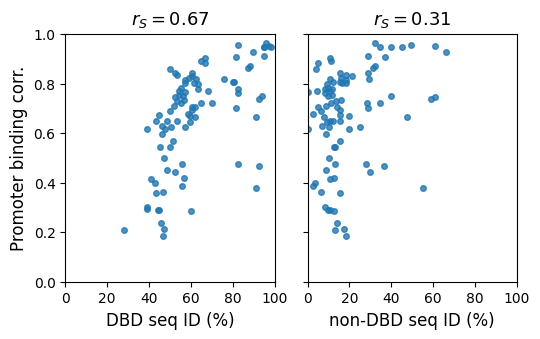

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(5.5, 3.5), sharey=True)

for ax, pts, xtitle in [
    (axes[0], pts_dbd, "DBD seq ID (%)"),
    (axes[1], pts_nonDBD, "non-DBD seq ID (%)")
]:
    x, y = pts.T
    ax.scatter(x, y, s=16, alpha=0.8)

    r, _ = spearmanr(x, y)
    ax.text(0.5, 1.02, rf"$r_S = {r:.2f}$",
            transform=ax.transAxes,
            ha="center", va="bottom", fontsize=13)

    ax.set_xlabel(xtitle, fontsize=12)

    ax.set_xlim(0,100)
    ax.set_ylim(0,1)

axes[0].set_ylabel("Promoter binding corr.", fontsize=12)

plt.tight_layout()
plt.show()